In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [72]:
df = pd.read_csv(r'D:\All codes\DataScienceJourney\Dv analytics\ML\UDEMY\Ridge Lassso Elastic Regression Practicals\Algerian_forest_fires_dataset_UPDATE.csv' , header=1)
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [73]:
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [75]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [76]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [77]:
##we can remove the unnessesary header like so 
# df.drop(index=122).isnull().count()


In [78]:
# as we know the dataset is divided into 2 regions 
# 1- bejaia region dataset = 0
# 2- sidi-bel abbes region = 1
# at index 122 
# we can simply create a new column "region" and assign 0 and 1  


In [79]:
df.loc[:122 , 'region' ] = 0
df.loc[122: , 'region'] =1
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [80]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [81]:
df = df.dropna().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    object 
 1   month        244 non-null    object 
 2   year         244 non-null    object 
 3   Temperature  244 non-null    object 
 4    RH          244 non-null    object 
 5    Ws          244 non-null    object 
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    object 
 13  Classes      244 non-null    object 
 14  region       244 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.7+ KB


In [82]:
df['region'] = df['region'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    object
 1   month        244 non-null    object
 2   year         244 non-null    object
 3   Temperature  244 non-null    object
 4    RH          244 non-null    object
 5    Ws          244 non-null    object
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      244 non-null    object
 14  region       244 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.7+ KB


In [83]:
df.loc[122]
df = df.drop(index=122).reset_index(drop=True)

changing the datatypes

In [84]:
df[df.iloc[: , :6].columns] = df[df.iloc[: , :6].columns].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4    RH          243 non-null    int64 
 5    Ws          243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


In [85]:
df[df.iloc[: , 6:13].columns] = df[df.iloc[: , 6:13].columns].astype(float)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [86]:
# df.rename(columns=)
df.columns = df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='object')

In [87]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire') , 0 , 1 )
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [88]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [89]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [90]:
df.select_dtypes('number').describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.563786,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.496938,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,1.000000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000,1.000000


plot density plot for all features

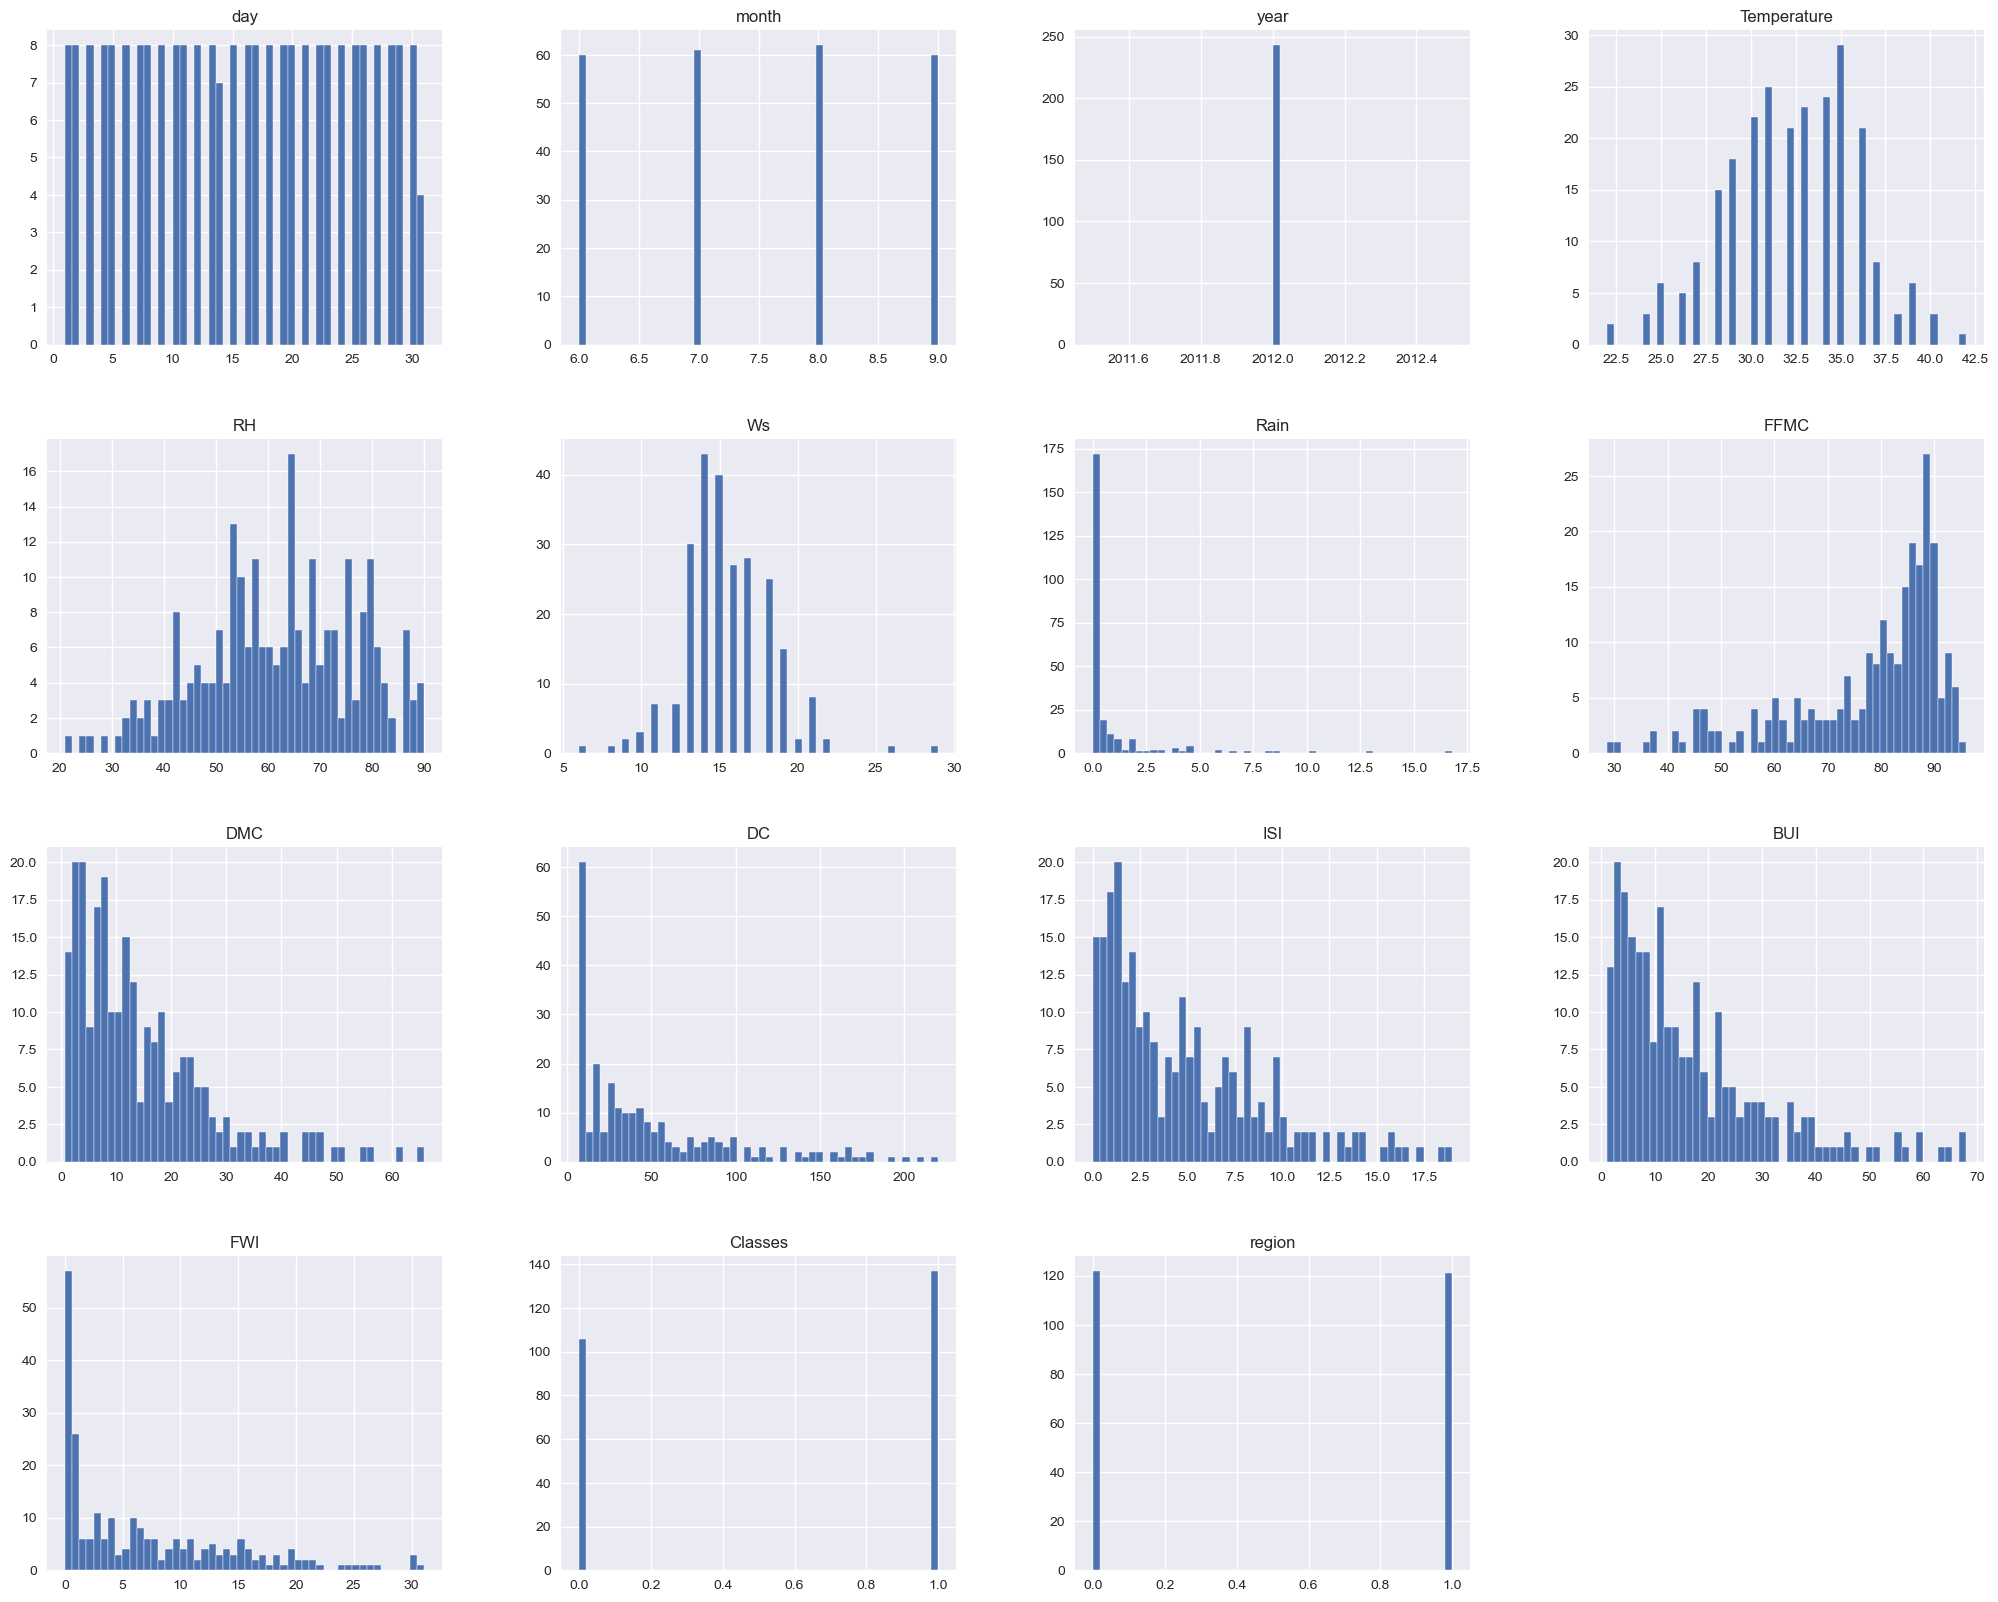

In [91]:
plt.style.use('seaborn-v0_8')
df.hist(bins=50,figsize=(25,20))
plt.show()

# plt.style.available

In [92]:
df['Classes'].value_counts(normalize=True)*100

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

In [93]:
df.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
day,1.000000,-0.000369,NaN,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821
month,-0.000369,1.000000,NaN,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097227,-0.056781,NaN,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.076034,-0.041252,NaN,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.047812,-0.039880,NaN,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.112523,0.034822,NaN,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.224956,0.017030,NaN,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.491514,0.067943,NaN,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.527952,0.126511,NaN,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734


<Axes: >

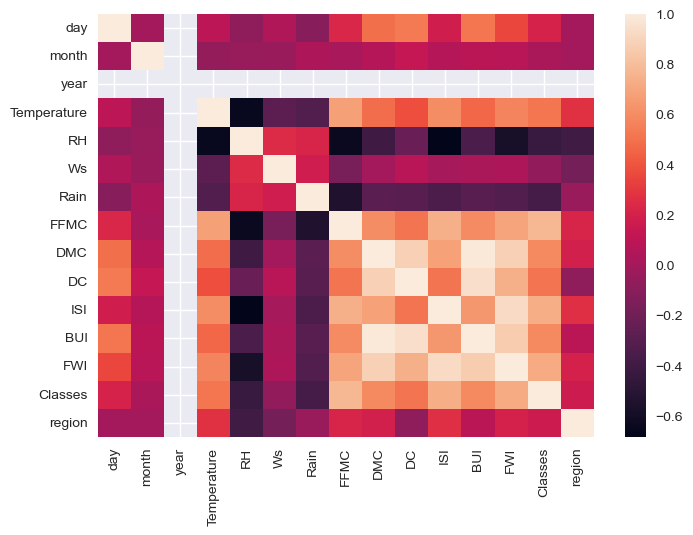

In [94]:
sns.heatmap(df.corr())

Text(0.5, 1.0, 'monthly fire analysis of bejai region')

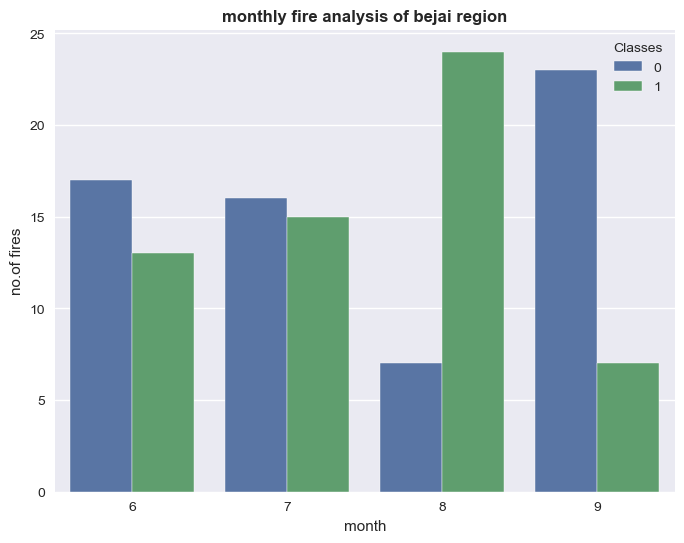

In [95]:
# monthly fire analysis of bejai region
dfr0 =  df[df['region']==0]
plt.subplots(figsize=(8,6))
sns.set_style('whitegrid')
sns.countplot(x='month' , hue='Classes' , data=dfr0 )
plt.ylabel('no.of fires')
plt.xlabel('month')
plt.title('monthly fire analysis of bejai region' , weight='bold')

Text(0.5, 1.0, 'monthly fire analysis of sidi-bel region')

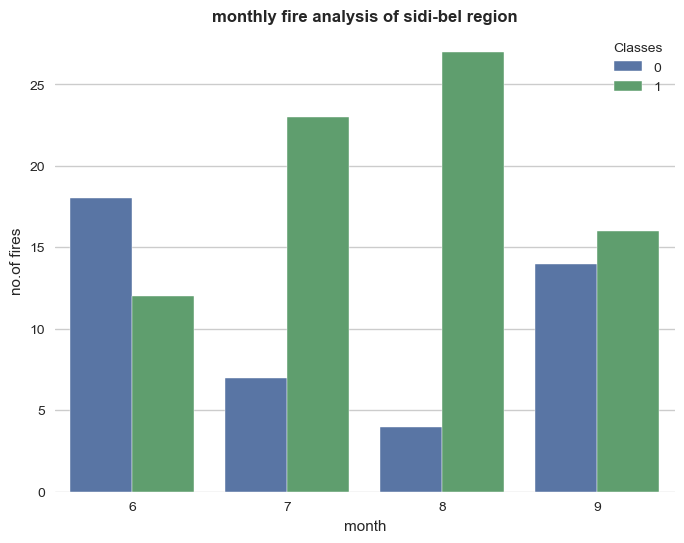

In [96]:
# monthly fire analysis of sidi-bel region
dfr1 =  df[df['region']==1]
plt.subplots(figsize=(8,6))
sns.set_style('whitegrid')
sns.countplot(x='month' , hue='Classes' , data=dfr1 )
plt.ylabel('no.of fires')
plt.xlabel('month')
plt.title('monthly fire analysis of sidi-bel region' , weight='bold')

In [97]:
X = df.drop(columns='FWI')
y = df['FWI']
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [98]:
X

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [99]:
#train test split 
from sklearn.model_selection import  train_test_split
x_train ,x_test, y_train   , y_test = train_test_split(X,y,test_size=0.25,random_state=45)
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((182, 14), (182,), (61, 14), (61,))

<Axes: >

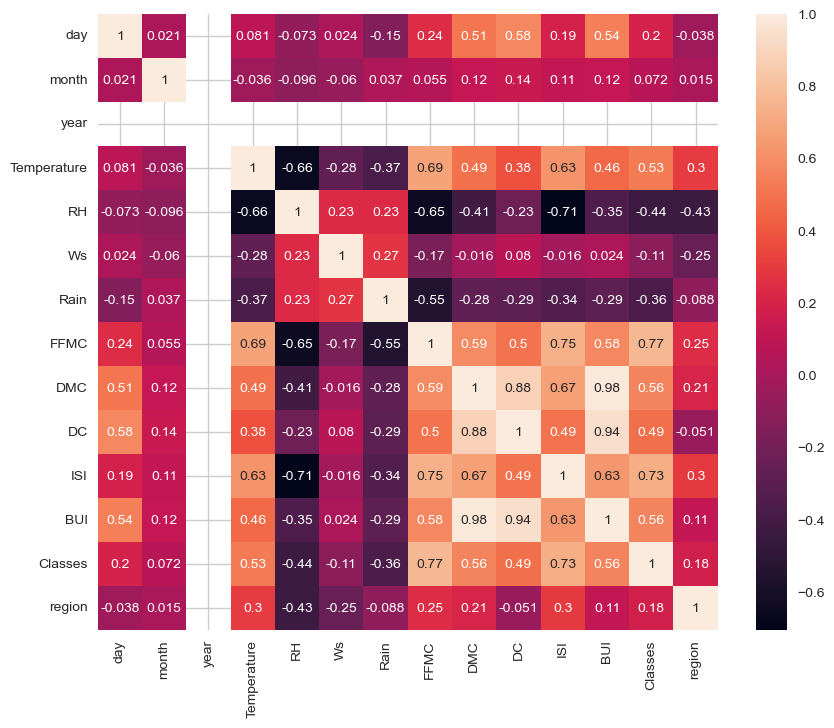

In [100]:
# feature selection based on correlation 
# checking for multicollinearity
corr = x_train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(data=corr , annot=True)




In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values , i )
                   for i  in range(x.shape[1])]
vif_data

,feature,VIF
0,day,1.487548
1,month,1.094968
2,year,553.931365
3,Temperature,2.421816
4,RH,3.205144
5,Ws,1.334699
6,Rain,1.577687
7,FFMC,4.952404
8,DMC,85.353688
9,DC,25.416664


In [102]:
dfdrop1 = X.drop(columns=['BUI','year'])

x = add_constant(dfdrop1)

vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values , i )
                   for i  in range(x.shape[1])]
vif_data

,feature,VIF
0,const,553.930878
1,day,1.486716
2,month,1.092002
3,Temperature,2.419836
4,RH,3.201330
5,Ws,1.334366
6,Rain,1.572779
7,FFMC,4.942874
8,DMC,8.462683
9,DC,7.099017


In [103]:
x_train.drop(columns=['BUI','year'],inplace=True)
x_test.drop(columns=['BUI','year'],inplace=True)
x_train.shape , y_train.shape , x_test.shape

((182, 12), (182,), (61, 12))

<Axes: >

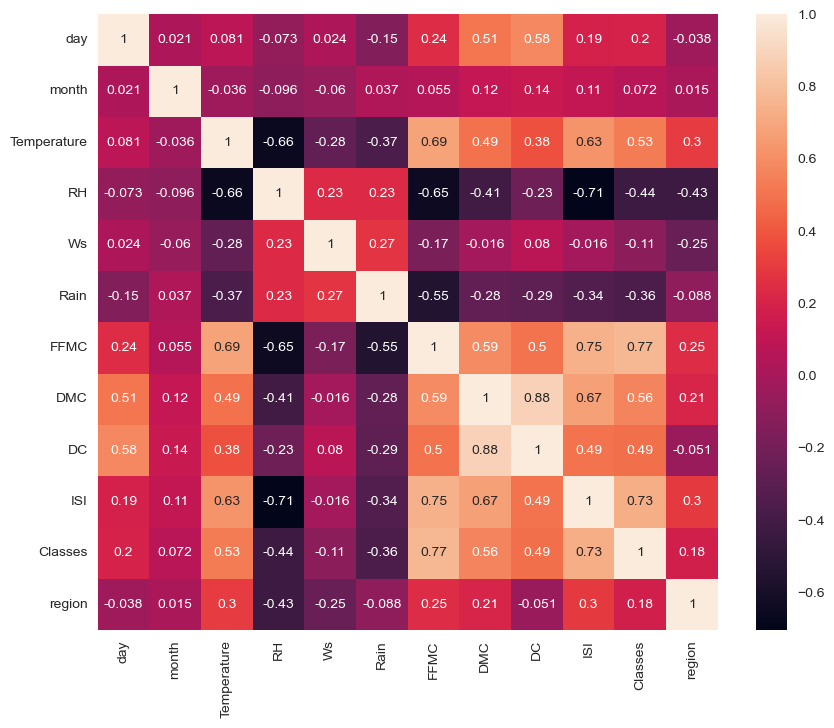

In [104]:
corr = x_train.corr()
plt.figure(figsize=(10,8))
sns.heatmap(data=corr , annot=True)

feature scaling or standardization

In [105]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled,x_test_scaled

(array([[ 1.13101281, -1.41023271,  1.03973391, ...,  0.54677005,
          0.85634884,  1.01105006],
        [ 1.36036583,  1.30098933, -0.03239964, ..., -0.71718494,
         -1.16774842, -0.98907071],
        [ 0.55763027,  1.30098933, -0.30043303, ...,  0.15786082,
          0.85634884, -0.98907071],
        ...,
        [-0.70381131, -1.41023271, -0.56846642, ...,  0.88706562,
          0.85634884,  1.01105006],
        [-1.04784084, -0.50649203,  1.57580069, ..., -0.15812793,
          0.85634884,  1.01105006],
        [ 0.67230678,  0.39724865,  1.3077673 , ...,  0.78983831,
          0.85634884,  1.01105006]]),
 array([[-1.27719385e+00,  3.97248650e-01,  5.03667137e-01,
         -1.30711137e+00,  5.78577631e-01, -3.18484456e-01,
          7.14407284e-01,  6.56863671e-01,  8.63138733e-04,
          3.46358924e+00,  8.56348839e-01,  1.01105006e+00],
        [ 1.13101281e+00,  1.30098933e+00, -3.00433029e-01,
         -5.20467329e-01, -1.63053696e+00, -3.66191593e-01,
          2.

box plot to understand effect of standard scaler

Text(0.5, 1.0, 'x_train after scaling ')

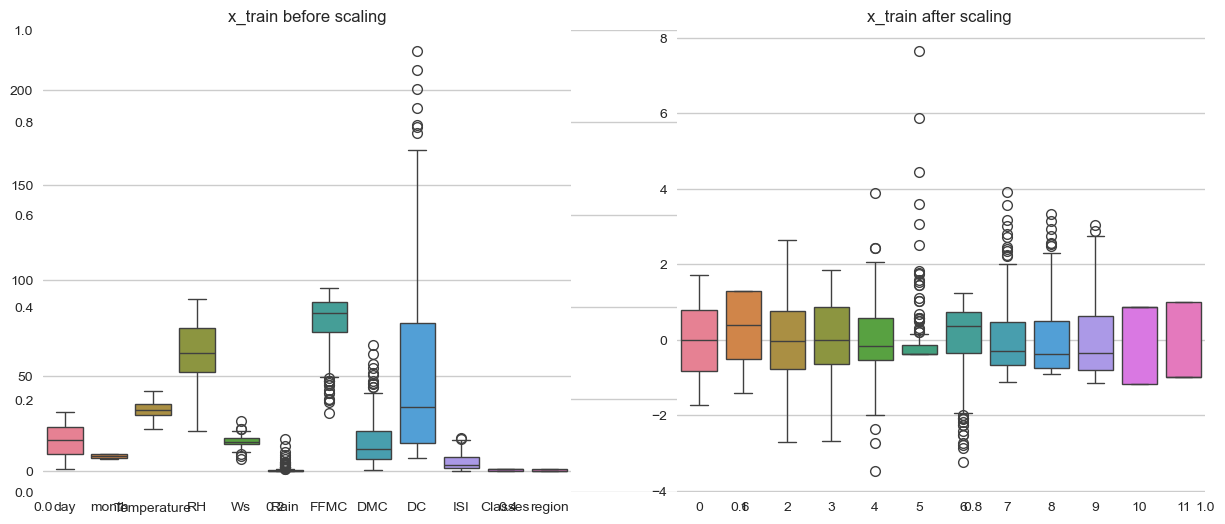

In [106]:
plt.subplots(figsize=(15,6))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('x_train after scaling ')


#model training

 train mae-  0.5542129236046928    test mae -  0.6982025805346894
 train mse-  0.6640434320915782    test mse -  4.109499872326805
train r2 score -  0.988531297674855   test r2 score -  0.9116332702616399


Text(0, 0.5, 'pred')

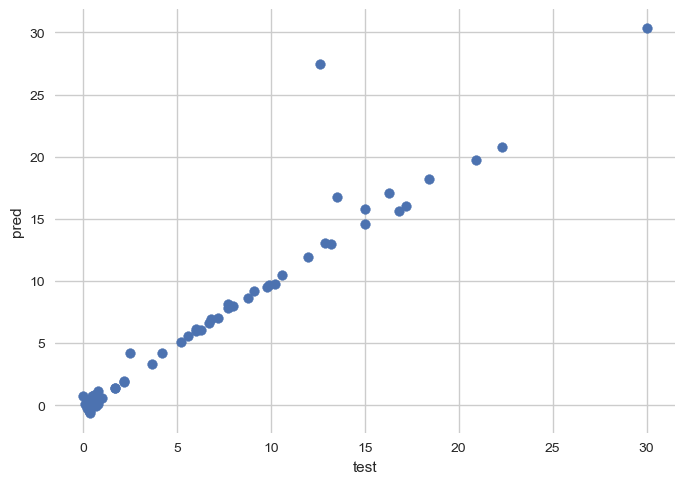

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
linreg1 = LinearRegression()
linreg1.fit(x_train_scaled,y_train)



y_train_pred = linreg1.predict(x_train_scaled)
y_test_pred = linreg1.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')


lasso regression model


 train mae-  1.1628478161667388    test mae -  1.1873371899890501
 train mse-  2.417240375339759    test mse -  3.93722727642275
train r2 score -  0.958251811593447   test r2 score -  0.9153376543464506


Text(0, 0.5, 'pred')

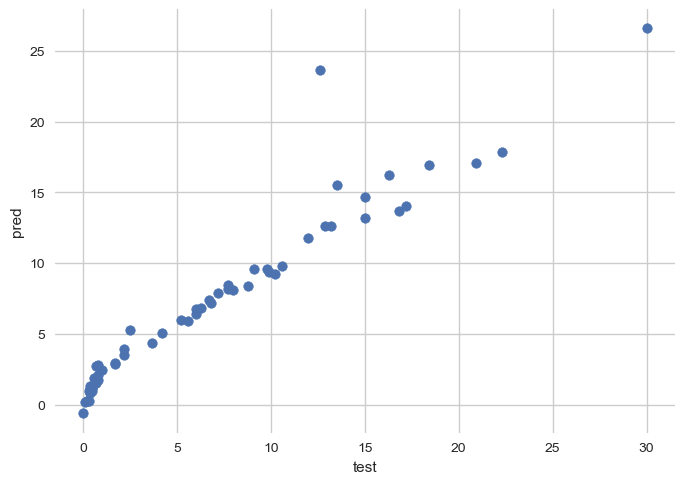

In [108]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lasso = Lasso()
lasso.fit(x_train_scaled,y_train)
y_train_pred = lasso.predict(x_train_scaled)
y_test_pred = lasso.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')


In [109]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled , y_train)

LassoCV(cv=5)

In [110]:
lassocv.alpha_

np.float64(0.021660907485739345)

In [111]:
lassocv.alphas_

array([7.09297065, 6.61492817, 6.16910415, 5.75332717, 5.36557218,
       5.00395057, 4.66670105, 4.35218102, 4.05885858, 3.7853051 ,
       3.53018821, 3.29226534, 3.07037767, 2.86344449, 2.67045792,
       2.49047799, 2.32262811, 2.16609075, 2.02010348, 1.88395527,
       1.75698299, 1.63856822, 1.5281342 , 1.42514307, 1.3290932 ,
       1.23951676, 1.15597748, 1.07806847, 1.00541026, 0.93764898,
       0.87445457, 0.81551926, 0.76055599, 0.70929706, 0.66149282,
       0.61691041, 0.57533272, 0.53655722, 0.50039506, 0.46667011,
       0.4352181 , 0.40588586, 0.37853051, 0.35301882, 0.32922653,
       0.30703777, 0.28634445, 0.26704579, 0.2490478 , 0.23226281,
       0.21660907, 0.20201035, 0.18839553, 0.1756983 , 0.16385682,
       0.15281342, 0.14251431, 0.13290932, 0.12395168, 0.11559775,
       0.10780685, 0.10054103, 0.0937649 , 0.08744546, 0.08155193,
       0.0760556 , 0.07092971, 0.06614928, 0.06169104, 0.05753327,
       0.05365572, 0.05003951, 0.04666701, 0.04352181, 0.04058

In [112]:
lassocv.coef_

array([ 0.        ,  0.        , -0.04810719,  0.        , -0.        ,
       -0.        , -0.91226942,  2.85984587,  0.67164231,  5.46057474,
        0.15747158, -0.15338726])

In [118]:
lassocv.mse_path_

array([[68.94264817, 94.96565083, 47.19676599, 41.33277872, 31.84725423],
       [64.32256179, 94.96565083, 42.12761595, 35.76708914, 28.09323664],
       [57.88328842, 94.96565083, 37.70177774, 30.94896234, 24.79605915],
       [52.22327577, 87.44524513, 33.71269286, 26.77698902, 21.37061933],
       [47.24503184, 77.99616764, 29.57901888, 23.16577473, 18.41342565],
       [42.86349296, 69.77386744, 25.97676688, 20.04114237, 15.8617615 ],
       [37.80469833, 62.61882342, 22.83708624, 17.33855984, 13.66179498],
       [33.22014855, 55.24483812, 20.10017309, 15.00206878, 11.76623904],
       [29.22322453, 48.59878275, 17.713983  , 12.98308263, 10.13423992],
       [25.73767118, 42.79938551, 15.63298193, 11.23927025,  8.73034635],
       [22.69750407, 37.73716545, 13.81826431,  9.73400971,  7.52380027],
       [20.04529152, 33.31836388, 12.23524126,  8.43545984,  6.48792046],
       [17.73056993, 29.45975578, 10.85404918,  7.31597868,  5.59941737],
       [15.71083384, 26.08941028,  9.6

 train mae-  0.5499467573540274    test mae -  0.672150514233494
 train mse-  0.6729377746474782    test mse -  4.015137256414409
train r2 score -  0.9883776833746124   test r2 score -  0.9136623531273887


Text(0, 0.5, 'pred')

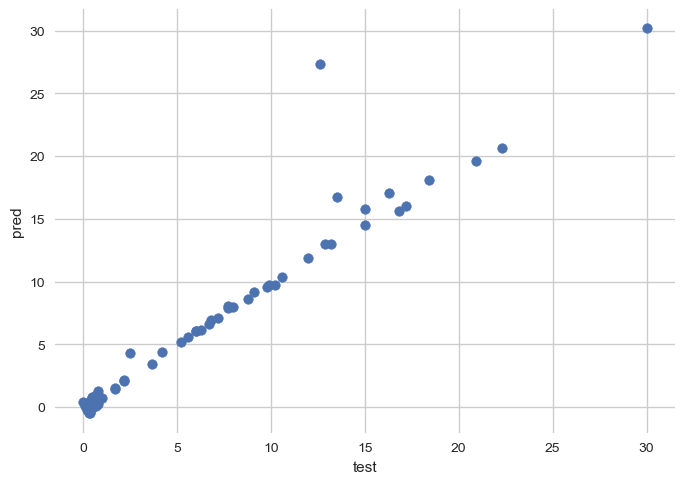

In [114]:
y_train_pred = lassocv.predict(x_train_scaled)
y_test_pred = lassocv.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')

Ridge regression model

 train mae-  0.5558696414701073    test mae -  0.6818710621814558
 train mse-  0.6678979253969755    test mse -  3.965480428992792
train r2 score -  0.9884647266733249   test r2 score -  0.9147301257480862


Text(0, 0.5, 'pred')

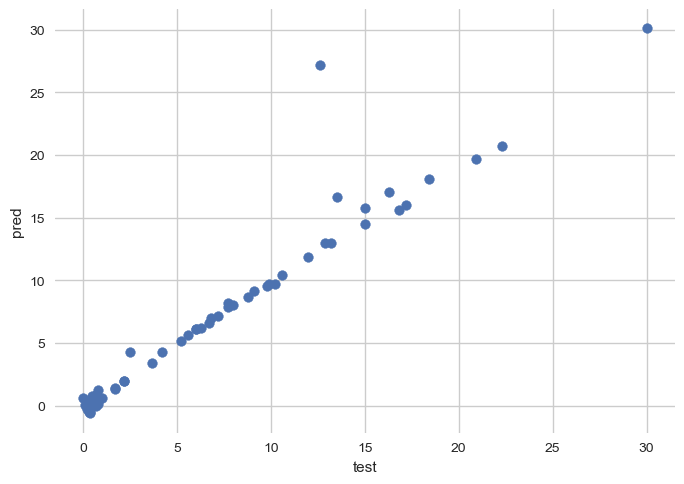

In [119]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
ridge = Ridge()
ridge.fit(x_train_scaled,y_train)
y_train_pred = ridge.predict(x_train_scaled)
y_test_pred = ridge.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')


 train mae-  0.5558696414701073    test mae -  0.6818710621814558
 train mse-  0.6678979253969755    test mse -  3.965480428992792
train r2 score -  0.9884647266733249   test r2 score -  0.9147301257480862


Text(0, 0.5, 'pred')

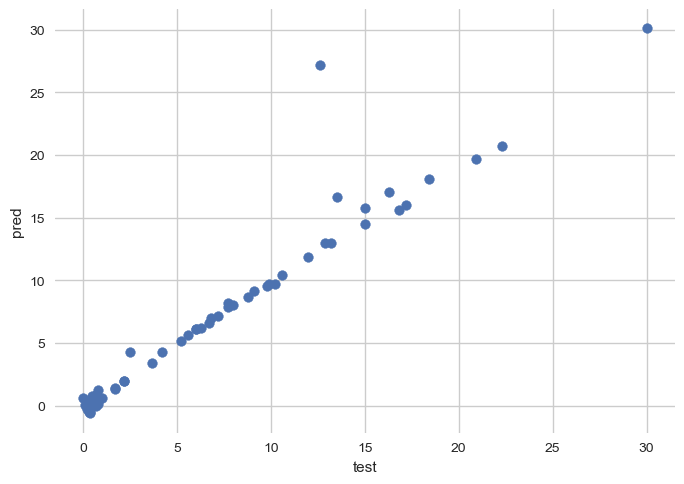

In [116]:
# ridgecv 
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV(cv=10)
ridgecv.fit(x_train_scaled , y_train)
y_train_pred = ridgecv.predict(x_train_scaled)
y_test_pred = ridgecv.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')




Elastic net model


 train mae-  1.731415735697364    test mae -  1.5242814559504705
 train mse-  5.380225507012102    test mse -  4.533436893873096
train r2 score -  0.9070780587532953   test r2 score -  0.9025173366023318


Text(0, 0.5, 'pred')

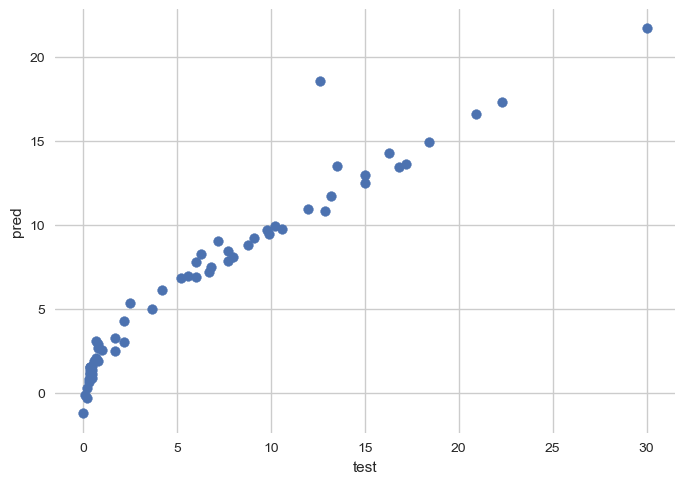

In [117]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
elasticnet = ElasticNet()
elasticnet.fit(x_train_scaled,y_train)
y_train_pred = elasticnet.predict(x_train_scaled)
y_test_pred = elasticnet.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')


 train mae-  0.5553875770767803    test mae -  0.6678664359055845
 train mse-  0.6739746457402206    test mse -  3.906549397228286
train r2 score -  0.988359775561151   test r2 score -  0.915997321932275


Text(0, 0.5, 'pred')

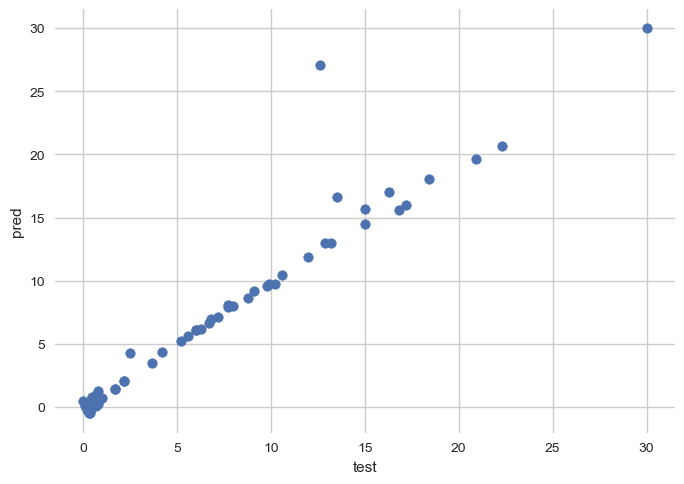

In [120]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(x_train_scaled,y_train)
y_train_pred = elasticnetcv.predict(x_train_scaled)
y_test_pred = elasticnetcv.predict(x_test_scaled)
train_mae = mean_absolute_error(y_train , y_train_pred)
test_mae = mean_absolute_error(y_test , y_test_pred)
train_mse = mean_squared_error(y_train , y_train_pred)
test_mse = mean_squared_error(y_test , y_test_pred)
train_r2 = r2_score(y_train , y_train_pred)
test_r2 = r2_score(y_test , y_test_pred)
print(" train mae- " , train_mae , "   test mae - " , test_mae)
print(" train mse- " , train_mse , "   test mse - " , test_mse)
print("train r2 score - " , train_r2 , "  test r2 score - " , test_r2)
plt.scatter(y_test , y_test_pred)
plt.xlabel('test')
plt.ylabel('pred')


In [121]:
elasticnetcv

ElasticNetCV(cv=5)

In [122]:
scaler

StandardScaler()

In [123]:
import pickle

pickle.dump(scaler, open('scaler.pkl' , 'wb'))
pickle.dump(elasticnetcv , open('elasticnetcv.pkl' , 'wb'))